<a href="https://colab.research.google.com/github/yogitaalone04-web/cifar10-augmentation-overfitting/blob/main/DL_data_augmentation_pipeline_CS24D017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Augmentation Pipeline — Yogita Alone (CS24D017)


**Project:** Data Augmentation (Rotation, Flip, Crop) for Image Classifier to Reduce Overfitting

**My part:** Load CIFAR-10 dataset, build augmented and baseline transforms.

## Step 1: Install & Import Libraries

In [ ]:
!pip install torch torchvision matplotlib --quiet

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## Step 2: Define Transforms

Two versions: one WITH augmentation (rotation, flip, crop), one WITHOUT (baseline) — needed for comparison later.

In [ ]:
# Augmented transform: rotation + horizontal flip + random crop
augmented_transform = transforms.Compose([
    transforms.RandomRotation(15),             # rotate randomly between -15 and +15 degrees
    transforms.RandomHorizontalFlip(p=0.5),     # 50% chance of horizontal flip
    transforms.RandomCrop(32, padding=4),       # pad then randomly crop back to 32x32
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Baseline transform: no augmentation, just tensor + normalize
baseline_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Transforms defined successfully.")

Transforms defined successfully.


## Step 3: Load CIFAR-10 Dataset

Downloads automatically (~170MB) — no manual dataset download needed.

In [ ]:
train_aug = datasets.CIFAR10(root='./data', train=True, download=True, transform=augmented_transform)
train_base = datasets.CIFAR10(root='./data', train=True, download=True, transform=baseline_transform)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=baseline_transform)

print(f"Full training set size: {len(train_aug)}")
print(f"Test set size: {len(test_set)}")

100%|██████████| 170M/170M [46:38<00:00, 60.9kB/s]


Full training set size: 50000
Test set size: 10000


## Step 4: Take a Small Subset

Using a small subset (2000 images) makes the model overfit faster on the baseline — which is exactly what we want to demonstrate augmentation fixing.

In [ ]:
SUBSET_SIZE = 2000

train_aug = torch.utils.data.Subset(train_aug, range(SUBSET_SIZE))
train_base = torch.utils.data.Subset(train_base, range(SUBSET_SIZE))

print(f"Using subset of {SUBSET_SIZE} images for training.")

Using subset of 2000 images for training.


## Step 5: Create DataLoaders

These three loaders (`loader_aug`, `loader_base`, `test_loader`) are the final output.

In [ ]:
loader_aug = DataLoader(train_aug, batch_size=64, shuffle=True)
loader_base = DataLoader(train_base, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

print("DataLoaders ready: loader_aug, loader_base, test_loader")

DataLoaders ready: loader_aug, loader_base, test_loader


## Step 6: Verify Augmentation Visually

Save a sample image to show the augmentation is actually working.

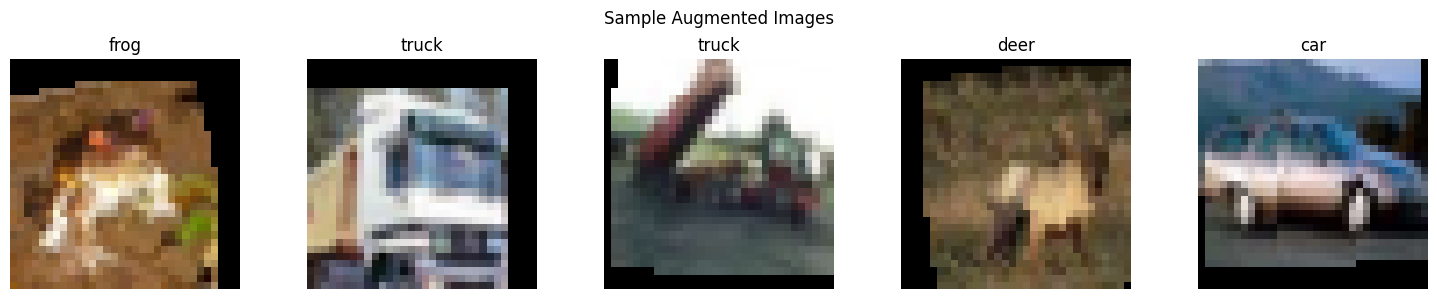

Saved sample_augmented.png — use this in the README/report.


In [ ]:
 classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img, label = train_aug[i]
    img_display = img.permute(1, 2, 0) * 0.5 + 0.5  # unnormalize for display
    axes[i].imshow(img_display)
    axes[i].set_title(classes[label])
    axes[i].axis('off')

plt.suptitle('Sample Augmented Images')
plt.tight_layout()
plt.savefig('sample_augmented.png')
plt.show()

print("Saved sample_augmented.png — use this in the README/report.")

CNN Architecture

In [ ]:
# Step 7: Build CNN Model

import torch.nn as nn
import torch.optim as optim

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Convolution + ReLU + Pooling
        self.conv_layers = nn.Sequential(

            # Conv Layer 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Conv Layer 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Conv Layer 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Flatten + Dense Layers
        self.fc_layers = nn.Sequential(
            nn.Flatten(),

            # 32x32 -> 16x16 -> 8x8 -> 4x4
            nn.Linear(128 * 4 * 4, 128),

            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


model = CNNModel().to(device)

print(model)

NameError: name 'torch' is not defined